# Manual Graph of Thoughts Demo
This example shows how to use the `pure_graph_of_thoughts` package for manual graph of operations construction.

The example task `sum_list` (defined in `sum_list.py`) is used.

## Construct Graph of Operations
The graph of operations is constructed.

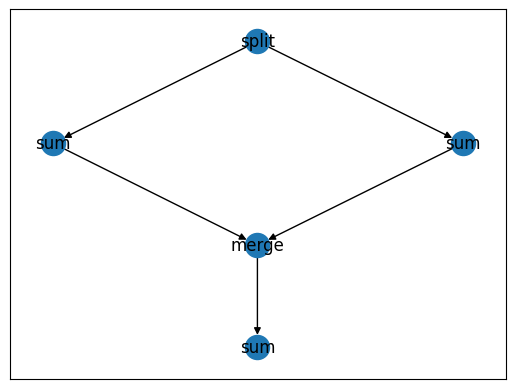

In [1]:
from sum_list import op_split, op_merge, op_sum
from pure_graph_of_thoughts.api.graph.operation import OperationNode, GraphOfOperations
from pure_graph_of_thoughts.visualization import plot_graph

def _create_sum_list_graph_of_operations() -> GraphOfOperations:
    source = OperationNode.of(op_split)
    for _ in (1, 2):
        source.append_operation(op_sum)
    aggregate = OperationNode.of(op_merge)
    for branch in source.successors:
        branch.append(aggregate)

    aggregate.append_operation(op_sum)

    return GraphOfOperations.from_source(source)


sum_list_graph_of_operations: GraphOfOperations = _create_sum_list_graph_of_operations()
plot_graph(sum_list_graph_of_operations)

## Execute Graph of Operations
The model `gpt-oss:20b` is used as the executing language model.

In [2]:
from pure_graph_of_thoughts.language_model import OllamaLanguageModel
from pure_graph_of_thoughts.controller import CompleteGraphController
import logging
logging.basicConfig(level=logging.INFO)

ollama = OllamaLanguageModel(model='gpt-oss:20b')
ctrl = CompleteGraphController(
    language_model=ollama
)

INFO:CompleteGraphController:Traversing node 1a5f661c-02f8-4dc4-b0cd-89b06eb6a3dd
INFO:CompleteGraphController:Processing operation PromptOperation(name='split', n_inputs=1, n_outputs=2, type=<OperationType.GENERATE: 'generate'>, output_complexity=Fraction(1, 2))
INFO:httpx:HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
INFO:CompleteGraphController:Traversing node e989284f-d7ab-4666-8297-7d021109c490
INFO:CompleteGraphController:Processing operation PromptOperation(name='sum', n_inputs=1, n_outputs=1, type=<OperationType.GENERATE: 'generate'>, output_complexity=1)
INFO:httpx:HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
INFO:CompleteGraphController:Traversing node 27bc8027-a6d8-477f-99fe-f05a14ab322b
INFO:CompleteGraphController:Processing operation PromptOperation(name='sum', n_inputs=1, n_outputs=1, type=<OperationType.GENERATE: 'generate'>, output_complexity=1)
INFO:httpx:HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK

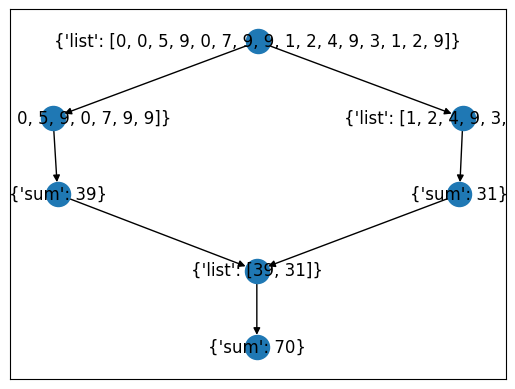

In [3]:
list = [0, 0, 5, 9, 0, 7, 9, 9, 1, 2, 4, 9, 3, 1, 2, 9]
sum_list_graph_of_thoughts = ctrl.execute_graph(sum_list_graph_of_operations, init_state={
    'list': list
})
plot_graph(sum_list_graph_of_thoughts)

The sum is correct.

In [4]:
sum(list)

70